---

## Phase 3 — Validation SHAP

---

In [4]:
import pandas as pd
import numpy as np
import shap
import lightgbm as lgb
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

### Chargement df_train enrichi

In [5]:
DATA_PATH = "data/"

df_train = pd.read_parquet(DATA_PATH + "df_train_phase3.parquet")
print(f"Shape : {df_train.shape}")
df_train.head()

Shape : (307511, 210)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PREV_AMT_CREDIT_MEAN,INSTAL_COUNT,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DAYS_LATE_MEAN,CC_COUNT,CC_AMT_BALANCE_MEAN,CC_AMT_DRAWINGS_MEAN,POS_COUNT,POS_MONTHS_BALANCE_MEAN,POS_SK_DPD_MEAN
0,100002,1,0,1,0,1,0,202500.0,406597.5,24700.5,...,179055.00,19.0,11559.247105,-20.421053,22.0,26793.606316,3473.671875,19.0,-10.000000,0.0
1,100003,0,0,0,0,0,0,270000.0,1293502.5,35698.5,...,484191.00,25.0,64754.586000,-7.160000,22.0,26793.606316,3473.671875,28.0,-43.785714,0.0
2,100004,0,1,1,1,1,0,67500.0,135000.0,6750.0,...,20106.00,3.0,7096.155000,-7.666667,22.0,26793.606316,3473.671875,4.0,-25.500000,0.0
3,100006,0,0,0,0,1,0,135000.0,312682.5,29686.5,...,291695.50,16.0,62947.088438,-19.375000,6.0,0.000000,0.000000,21.0,-9.619048,0.0
4,100007,0,0,1,0,1,0,121500.0,513000.0,21865.5,...,166638.75,66.0,12214.060227,-3.636364,22.0,26793.606316,3473.671875,66.0,-33.636364,0.0


### Entraînement LightGBM rapide

In [6]:
X = df_train.drop(columns=["TARGET", "SK_ID_CURR"])
y = df_train["TARGET"]

import re
X.columns = [re.sub(r"[^\w]", "_", col) for col in X.columns]

model = LGBMClassifier(n_estimators=100, random_state=42)
model.fit(X, y)
print("Entraînement terminé.")

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.258038 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9428
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
Entraînement terminé.


### Validation SHAP

In [10]:
import os

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

vals = shap_values[1] if isinstance(shap_values, list) else shap_values
expected = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value

GRAPH_PATH = "graphiques/"
os.makedirs(GRAPH_PATH, exist_ok=True)

print("SHAP values calculées.")

SHAP values calculées.


/home/bdb/Bureau/P6/Initiez-vous-au-MLOps/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


#### Beeswarm — impact et direction par feature

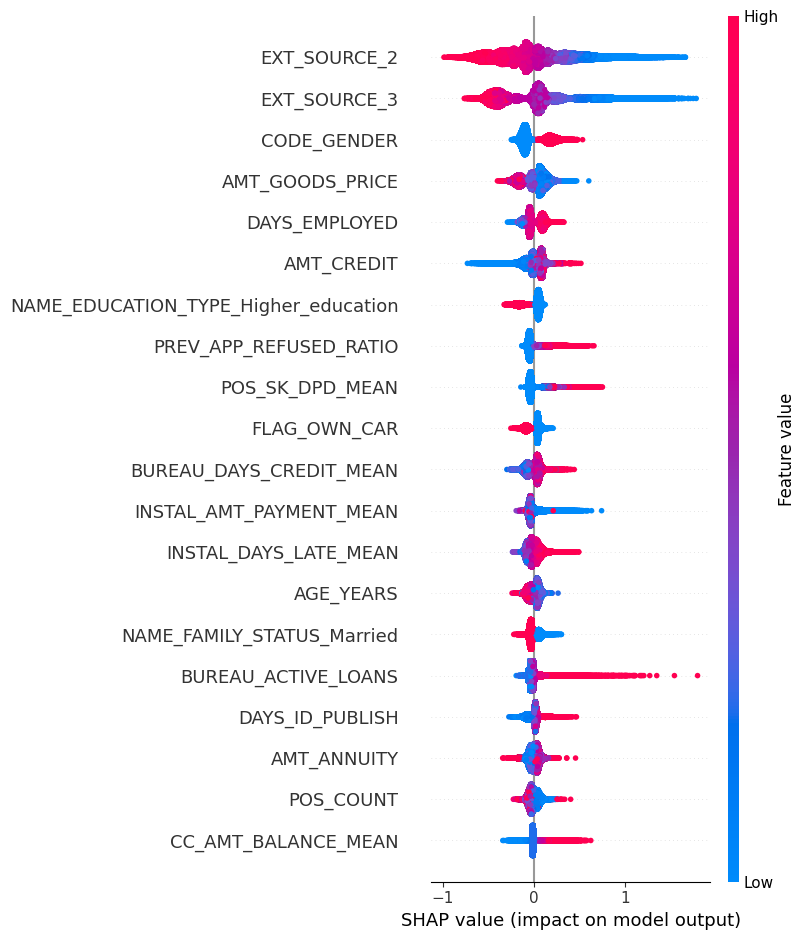

shap_beeswarm.png sauvegardé.


In [11]:
shap.summary_plot(vals, X, max_display=20, show=False)
plt.savefig(GRAPH_PATH + "shap_beeswarm.png", bbox_inches="tight", dpi=150)
plt.show()
print("shap_beeswarm.png sauvegardé.")

#### Bar plot — importance moyenne absolue

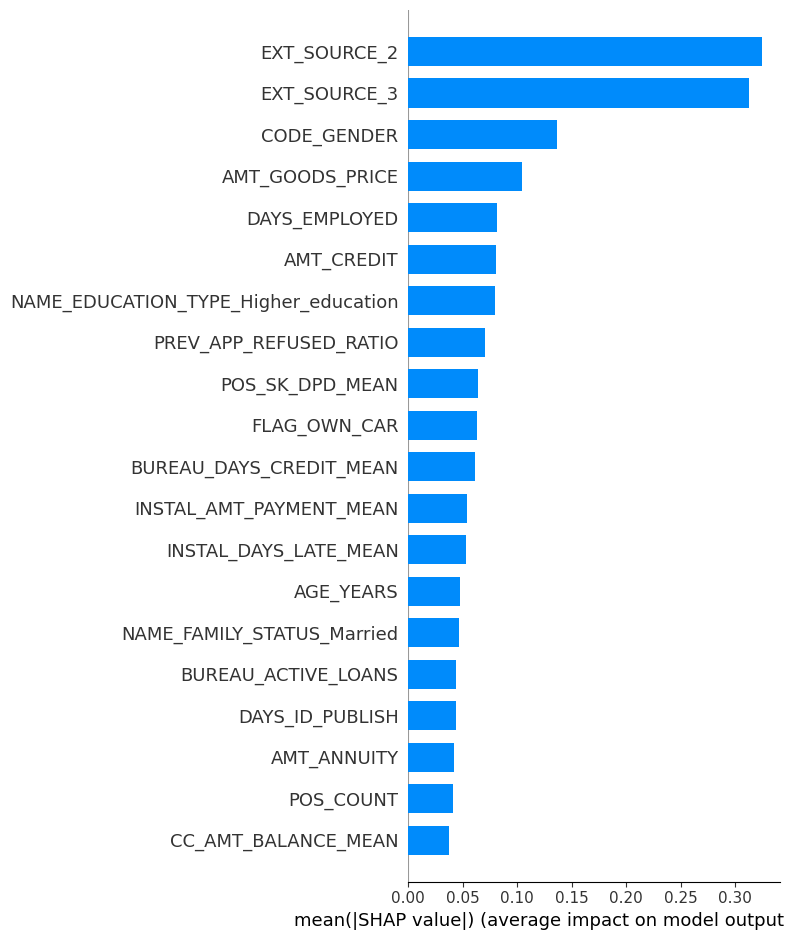

shap_bar.png sauvegardé.


In [12]:
shap.summary_plot(vals, X, plot_type="bar", max_display=20, show=False)
plt.savefig(GRAPH_PATH + "shap_bar.png", bbox_inches="tight", dpi=150)
plt.show()
print("shap_bar.png sauvegardé.")

#### Dependence plot — feature la plus importante

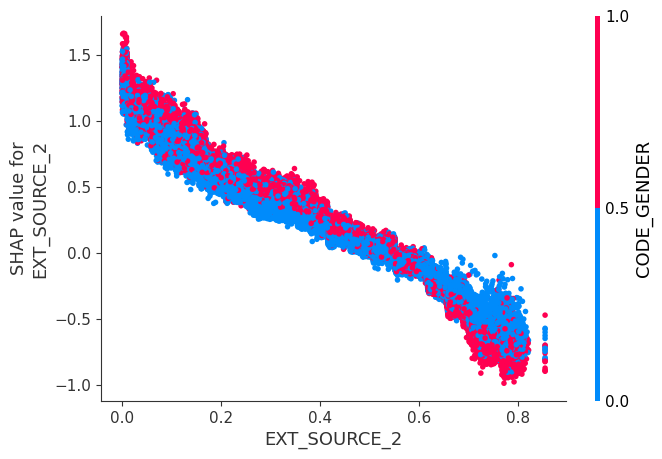

shap_dependence.png sauvegardé (EXT_SOURCE_2).


In [13]:
top_feature = X.columns[np.abs(vals).mean(axis=0).argmax()]
shap.dependence_plot(top_feature, vals, X, show=False)
plt.savefig(GRAPH_PATH + "shap_dependence.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"shap_dependence.png sauvegardé ({top_feature}).")

#### Waterfall — explication d'une observation individuelle

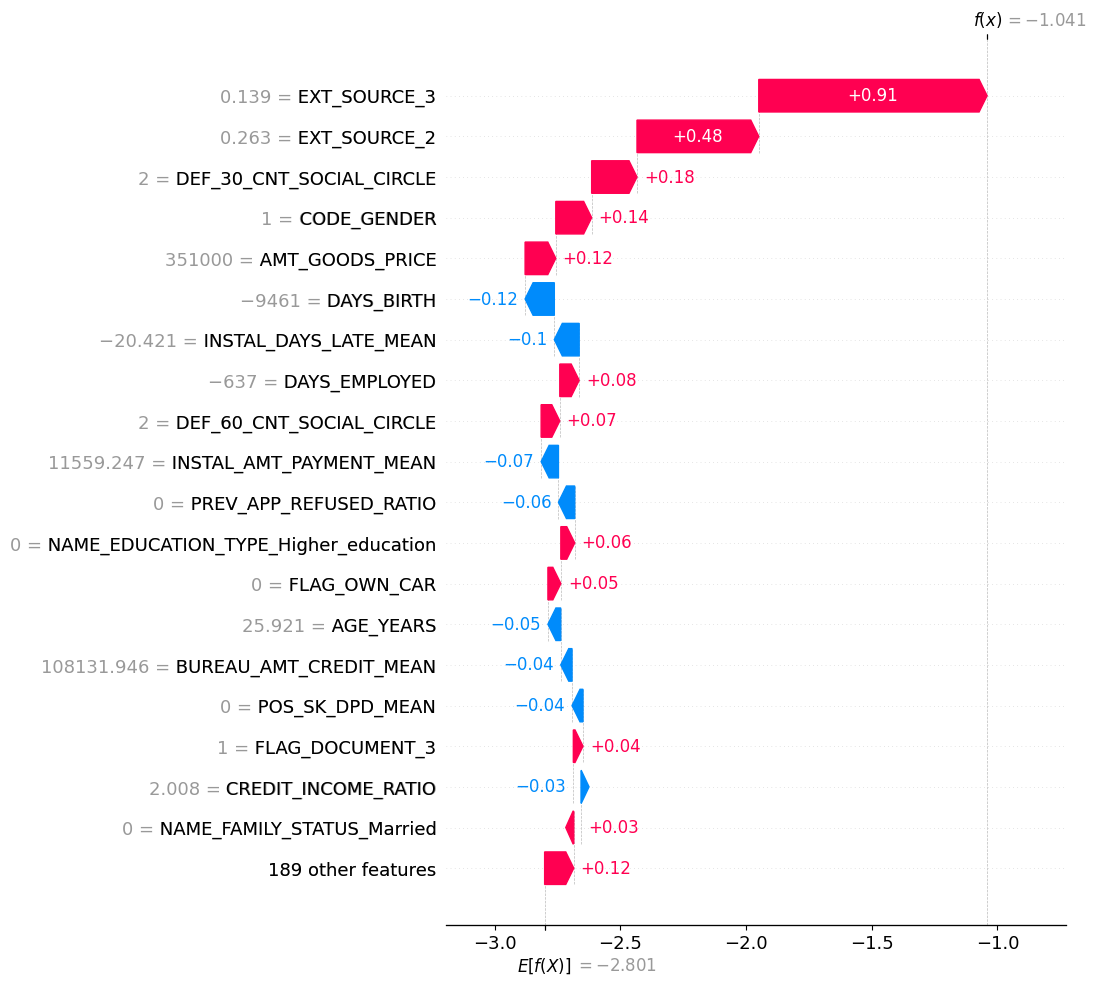

shap_waterfall.png sauvegardé.


In [14]:
explanation = shap.Explanation(
    values=vals[0],
    base_values=expected,
    data=X.iloc[0],
    feature_names=X.columns.tolist()
)
shap.plots.waterfall(explanation, max_display=20, show=False)
plt.savefig(GRAPH_PATH + "shap_waterfall.png", bbox_inches="tight", dpi=150)
plt.show()
print("shap_waterfall.png sauvegardé.")